# Scraping & classifying the pages the LLM surfaces

The clickstream dataframes carry **hundreds of thousands of links** — the URLs
the assistant cited in its answers and the pages users browsed right after each
turn. When only the raw export is available, everything needed lives in one
file: **`simweb_input_file.parquet`** (`a_links_source` = links cited in the
answer, `ai_click` = client-side clicks, and `next_10_urls` = the raw browsing
trail with per-request timestamps). This notebook demonstrates
`conveyer.scraping`, the module that turns those link columns into an
analysable dataset:

1. **Scrape** each URL (politely: robots.txt, per-domain rate limit, cache) and
   extract *everything the page offers* — title, meta/OpenGraph, headings, text,
   schema.org JSON-LD / microdata, links, images.
2. **Classify** the page into a funnel-mapped taxonomy — the three buckets the
   study asked for plus four proposed additions the data demands:

| `page_category` | Funnel stage | Origin |
|---|---|---|
| `brand_landing` | Discovery | requested |
| `catalogue` | Discovery | requested |
| `shopping` (seller: `brand_owned` / `retailer`) | Intent / Purchase | requested |
| `editorial` | Evaluation | **proposed** |
| `search` | Intent | **proposed** |
| `community` | Evaluation | **proposed** |
| `reference` | Awareness | **proposed** |
| `unrelated` / `unknown` | Irrelevant | requested / escape hatch |

3. **Extract the products** on each page (price, description, rating, category,
   SKU) and **match them to the product the agent mentioned** on the turn that
   surfaced the link, yielding a per-product `coincides` verdict.
4. **Persist incrementally** — each finished page is appended to a
   line-per-record JSONL sidecar the moment it completes, and the two-table
   parquet star (`fact_scraped_page` + `fact_scraped_product`,
   [`docs/SCRAPED_PAGES_SCHEMA.md`](../docs/SCRAPED_PAGES_SCHEMA.md)) is
   refreshed at checkpoints and on exit. **A long run can neither hang nor lose
   its work** (details in §2).

Like every conveyer module, it runs end-to-end **offline** on a synthetic
ground-truth corpus when the real data (or the network) is absent — so this
notebook executes anywhere, and doubles as the module's acceptance test.

## 1 · Setup & configuration

`ScrapeConfig` is safe by default: `offline=True` (no network), synthetic
fallback when no data is present. `clickstream_dir` accepts **either** the
star-schema directory **or a single parquet file** — pointing it at
`simweb_input_file.parquet` alone is fully supported.

The knobs that keep a real run bounded:

* `timeout` — socket connect/read timeout per request;
* `hard_timeout` — **wall-clock cap per URL**, covering robots.txt, every
  retry and slow-dribbling bodies. A server that keeps trickling bytes never
  trips a socket timeout — only a wall-clock budget stops it;
* `checkpoint_every` / `progress_every` — parquet refresh + progress cadence;
* `resume=True` — a re-run skips every page already in the JSONL sidecar.

In [1]:
import shutil, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / "conveyer").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

from conveyer.scraping import ScrapeConfig, run_scrape, CATEGORY_DEFINITIONS

DATA = ROOT / "data/similarweb_clickstream_data/simweb_input_file.parquet"
OUT = ROOT / "outputs/scrape_demo"
shutil.rmtree(OUT, ignore_errors=True)   # fresh demo run (no resume from old outputs)

cfg = ScrapeConfig(
    clickstream_dir=str(DATA),        # a single parquet file is enough
    offline=True,                     # flip to False (or --online) for real fetching
    synthetic_n_pages=60,             # corpus size when DATA is absent
    out_dir=str(OUT),
    timeout=10.0,                     # socket timeout per request
    hard_timeout=30.0,                # wall-clock cap per URL (robots + retries + body)
    max_urls=2000,                    # sample cap when running on the real 265k URLs
    checkpoint_every=200,
    progress_every=25,
    resume=True,
)
pd.set_option("display.max_colwidth", 60)

## 2 · Run the pipeline — incremental, interruption-safe

One call: resolve sources (the parquet file if present, synthetic corpus
otherwise) → stream fetches → extract / classify / match **as each URL
completes** → append to `scraped_pages.jsonl` / `scraped_products.jsonl` line
by line → refresh the parquet files at checkpoints and on exit → self-evaluate
when ground truth exists.

Why it cannot run forever or lose work, by construction:

* every URL has a **hard wall-clock budget** (`hard_timeout`) that covers
  robots.txt (fetched with a bounded timeout — the stdlib reader would block
  indefinitely on a dead host), all retries, and slow-dribbling bodies;
* the per-domain rate limiter **reserves a slot and sleeps outside the lock**,
  so one slow domain never serializes the other workers;
* results are processed **as they complete** (`as_completed`), not as a batch:
  the first page lands in the JSONL within seconds and `[progress]` lines
  report throughput and ETA;
* products are written first and the page line last (a **commit marker**), so a
  crash or Ctrl-C loses at most the single page in flight — and the next run
  **resumes**, redoing only what's missing.

In [2]:
art = run_scrape(cfg)
pages, products = art["pages"], art["products"]

[sources] SYNTHETIC (60 pages) | urls=60 | turns_with_mentions=7
[fetch] mode=offline | pending=60 | workers=8 | per-url cap=30s | line-by-line -> /home/user/conveyer/outputs/scrape_demo/scraped_pages.jsonl
[progress] 25/60 pages | ok=23 err=2 | 309.4 pages/s | eta 0.0 min


[progress] 50/60 pages | ok=46 err=4 | 461.5 pages/s | eta 0.0 min


[export] /home/user/conveyer/outputs/scrape_demo/scraped_pages.parquet (60 pages) | /home/user/conveyer/outputs/scrape_demo/scraped_products.parquet (54 products) | new this run: 60
[categories]
page_category
shopping         18
brand_landing     7
catalogue         7
editorial         6
community         6
unrelated         6
search            5
reference         5
[match] products=54 | coincide=41
[eval] {'n': 60.0, 'category_accuracy': 1.0, 'seller_accuracy': 1.0, 'coincide_accuracy': 1.0, 'coincide_precision': 1.0, 'coincide_recall': 1.0}


In [3]:
# the line-per-record sidecars land next to the parquet files
sorted(p.name for p in OUT.iterdir())

['scraped_pages.jsonl',
 'scraped_pages.parquet',
 'scraped_products.jsonl',
 'scraped_products.parquet']

## 3 · `fact_scraped_page` — one row per URL

Identity + fetch metadata + extracted page info + classification + provenance.
The full schema is in `docs/SCRAPED_PAGES_SCHEMA.md`; here is the analytical
core:

In [4]:
view_cols = ["url", "page_category", "page_subtype", "seller_type", "funnel_stage",
             "page_category_confidence", "skincare_relevance", "n_products",
             "has_price", "times_surfaced", "times_recommended", "prior_page_type"]
pages[view_cols].head(10)

,url,page_category,page_subtype,seller_type,funnel_stage,page_category_confidence,skincare_relevance,n_products,has_price,times_surfaced,times_recommended,prior_page_type
0,https://www.cerave.com/,brand_landing,brand_site,brand_owned,Discovery,1.000,1.00,0,False,31,3,brand_site
1,https://www.cerave.com/products/cerave-moisturizing-cream,shopping,pdp,brand_owned,Intent,0.989,0.60,2,True,29,4,pdp
2,https://www.amazon.com/products/cerave-moisturizing-cream,shopping,pdp,retailer,Intent,0.985,0.60,2,True,18,1,pdp
3,https://www.amazon.com/collections/moisturizers,catalogue,collection,retailer,Discovery,1.000,1.00,3,False,18,0,category
4,https://www.byrdie.com/best-moisturizers-for-dry-skin,editorial,article,na,Evaluation,0.948,1.00,1,True,28,4,
5,https://www.google.com/search?q=best+moisturizer+for+dry...,search,serp,na,Intent,1.000,1.00,0,False,52,0,
6,https://www.reddit.com/r/SkincareAddiction/comments/9829...,community,forum,na,Evaluation,1.000,0.75,0,False,19,0,
7,https://en.wikipedia.org/wiki/Moisturizer,reference,wiki,na,Awareness,1.000,1.00,0,False,53,0,
8,https://www.amazon.com/products/gaming-laptop-0,unrelated,pdp,retailer,Irrelevant,0.971,0.00,2,True,19,0,pdp
9,https://www.amazon.com/gp/cart/view.html?ref_=nav_cart,shopping,cart,retailer,Purchase,0.846,0.00,0,False,19,0,


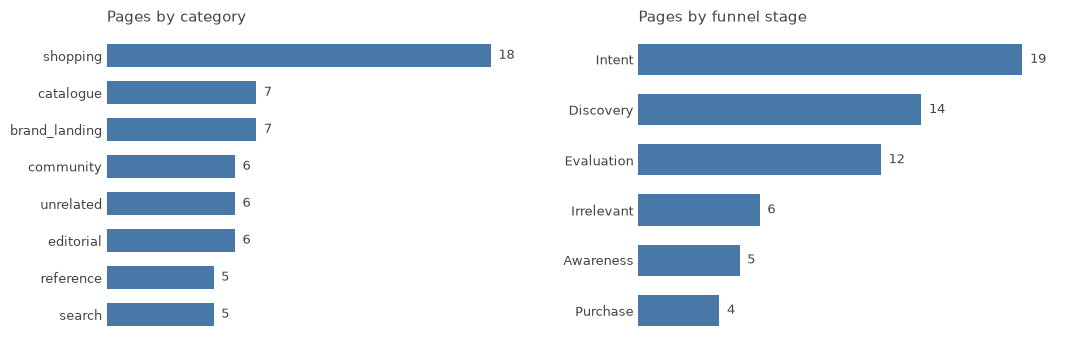

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
HUE, INK = "#4878a8", "#444444"

for ax, col, title in ((axes[0], "page_category", "Pages by category"),
                       (axes[1], "funnel_stage", "Pages by funnel stage")):
    counts = pages[col].value_counts().sort_values()
    ax.barh(counts.index, counts.values, color=HUE, height=0.62)
    for y, v in enumerate(counts.values):
        ax.text(v + max(counts.values) * 0.02, y, str(v), va="center",
                fontsize=9, color=INK)
    ax.set_title(title, fontsize=11, color=INK, loc="left")
    ax.tick_params(labelsize=9, colors=INK, length=0)
    ax.set_xlim(0, max(counts.values) * 1.15)
    for s in ("top", "right", "left", "bottom"):
        ax.spines[s].set_visible(False)
    ax.xaxis.set_visible(False)
plt.tight_layout()
plt.show()

### Seller split & the vendor prior

`seller_type` answers the requested "external retailer or brand owned" split as
an **orthogonal axis**, so `shopping` and `catalogue` don't each fork in two.
When the full star schema is available, `prior_page_type` keeps SimilarWeb's
own label verbatim and the classifier blends it as a prior
(`classifier_method = "rule+prior"`); the crosstab makes every disagreement
auditable. (In input-file-only mode there is no vendor prior — the classifier
stands alone on URL + markup.)

In [6]:
display(pd.crosstab(pages["page_category"], pages["seller_type"]))
with_prior = pages[pages["prior_page_type"] != ""]
pd.crosstab(with_prior["prior_page_type"], with_prior["page_subtype"])

seller_type,brand_owned,na,retailer
page_category,,,
brand_landing,7,0,0
catalogue,0,0,7
community,0,6,0
editorial,0,6,0
reference,0,5,0
search,0,5,0
shopping,7,0,11
unrelated,0,3,3


page_subtype,brand_site,collection,pdp
prior_page_type,,,
brand_site,7,0,0
category,0,7,0
pdp,0,0,17


### URL-only classification — the multimodal guarantee

Many surfaced URLs can never be fetched (bot walls, logins, dead links, carts).
The classifier is **multimodal** — URL tokens, domain knowledge, page markup
and the vendor prior vote independently, and any one can carry a page alone —
so obvious URLs classify correctly with **zero content**:
`amazon.com` + `/gp/cart/` *is* a retailer cart, fetched or not.
`classification_signals` records which modalities fired. Topic-neutral pages
(carts, checkouts, SERPs, storefront entries) are journey infrastructure and
are never demoted for lacking skincare tokens; a topical page (like an opaque
`/dp/ASIN` PDP) keeps its structural role, with `is_study_relevant` tracking
what we don't yet know.

In [7]:
from conveyer.scraping.classify import classify_rule
from conveyer.scraping.extract import extract_page

url_only = [
    "https://www.amazon.com/gp/cart/view.html?ref_=nav_cart",   # retailer cart
    "https://www.sephora.com/checkout",                          # retailer checkout
    "https://www.amazon.com/",                                   # storefront entry
    "https://www.amazon.com/dp/B00365FJ8K",                      # opaque PDP
    "https://www.google.com/search?q=best+retinol",              # SERP
    "https://www.reddit.com/r/SkincareAddiction/comments/1/x",   # community
    "https://someblog-nobody-knows.xyz/post/123",                # nothing to go on
]
pd.DataFrame([{
    "url": u, "category": c.page_category, "subtype": c.page_subtype,
    "seller": c.seller_type, "funnel": c.funnel_stage,
    "relevant": c.is_study_relevant, "signals": ", ".join(c.signals),
} for u in url_only for c in [classify_rule(extract_page("", u), u, cfg)]])

,url,category,subtype,seller,funnel,relevant,signals
0,https://www.amazon.com/gp/cart/view.html?ref_=nav_cart,shopping,cart,retailer,Purchase,True,"url, domain"
1,https://www.sephora.com/checkout,shopping,checkout,retailer,Purchase,True,"url, domain"
2,https://www.amazon.com/,catalogue,marketplace,retailer,Discovery,True,"url, domain"
3,https://www.amazon.com/dp/B00365FJ8K,shopping,pdp,retailer,Intent,False,"url, domain"
4,https://www.google.com/search?q=best+retinol,search,serp,na,Intent,True,"url, domain"
5,https://www.reddit.com/r/SkincareAddiction/comments/1/x,community,forum,na,Evaluation,False,domain
6,https://someblog-nobody-knows.xyz/post/123,unknown,other,na,Irrelevant,False,


## 4 · Attention ranking — dwell time from the browsing trail

`next_10_urls` records up to 10 requests after each turn, each with a
`request_time` (epoch ms). The gap to the **next** request is how long the user
stayed before moving on — a retention / relevancy signal. The **last** entry
has no successor, so its dwell is never guessed (it stays null). Per URL the
pipeline aggregates:

* `mean_dwell_seconds` / `total_dwell_seconds` — attention per visit / overall;
* `mean_trail_position` — how early after the answer the page tends to appear
  (1 = the first thing the user opened).

Read dwell as an **upper bound** on attention: the clock keeps running while
the user is idle or in another tab. Long dwell + early trail position on a
`shopping` page is the strongest behavioural signal short of a purchase flag.

In [8]:
trail = pages[pages["mean_dwell_seconds"].notna()]
rank_cols = ["url", "page_category", "funnel_stage", "times_visited",
             "mean_dwell_seconds", "total_dwell_seconds", "mean_trail_position"]
print(f"{len(trail)}/{len(pages)} pages appear in browsing trails")
trail.sort_values("total_dwell_seconds", ascending=False)[rank_cols].head(10)

55/60 pages appear in browsing trails


,url,page_category,funnel_stage,times_visited,mean_dwell_seconds,total_dwell_seconds,mean_trail_position
33,https://www.target.com/collections/exfoliants,catalogue,Discovery,14,99.192,1388.688,6.15
40,https://www.cetaphil.com/,brand_landing,Discovery,28,38.032,1064.896,3.30
2,https://www.amazon.com/products/cerave-moisturizing-cream,shopping,Intent,25,36.287,907.175,8.40
18,https://www.investopedia.com/articles/markets-1,unrelated,Irrelevant,27,30.613,826.551,8.06
3,https://www.amazon.com/collections/moisturizers,catalogue,Discovery,27,25.047,676.269,1.57
42,https://www.amazon.com/products/cetaphil-gentle-skin-cle...,shopping,Intent,29,19.208,557.032,9.04
12,https://www.sephora.com/products/the-ordinary-niacinamid...,shopping,Intent,24,21.332,511.968,8.03
10,https://www.theordinary.com/,brand_landing,Discovery,18,26.812,482.616,4.49
11,https://www.theordinary.com/products/the-ordinary-niacin...,shopping,Intent,24,20.022,480.528,2.80
15,https://www.google.com/search?q=best+serum+for+dry+skin,search,Intent,17,27.871,473.807,3.74


In [9]:
by_cat = (trail.groupby("page_category")["mean_dwell_seconds"]
          .agg(["count", "mean", "median"]).round(1)
          .sort_values("mean", ascending=False))
by_cat

,count,mean,median
page_category,,,
catalogue,6,27.9,16.0
unrelated,6,21.7,18.0
shopping,17,20.7,12.7
brand_landing,6,20.0,18.4
editorial,6,18.8,11.2
search,4,17.6,14.4
community,5,11.6,10.8
reference,5,10.9,11.4


## 5 · `fact_scraped_product` — products on the pages, matched to the chat

Product metadata comes from schema.org `Product` JSON-LD first (what Google
Shopping reads), then OpenGraph `product:*`, microdata, and a visible-price
heuristic — `extraction_source` records which. Each product is scored against
the entities the agent mentioned on the turn(s) that surfaced the page
(SKU > brand > name-overlap > category), and `coincides` fires when the score
clears `cfg.coincide_threshold` (0.5). In input-file-only mode there is no
entity table, so products carry their metadata with `match_type = "none"` —
the matching lights up as soon as `fact_ai_recommendation` is added.

In [10]:
meta_cols = ["name", "brand", "price", "currency", "rating", "rating_count",
             "category", "extraction_source"]
products[meta_cols].head(8)

,name,brand,price,currency,rating,rating_count,category,extraction_source
0,CeraVe Moisturizing Cream,CeraVe,16.99,USD,4.7,21843.0,moisturizer,jsonld
1,CeraVe Moisturizing Cream | Buy Online,,NaN,,NaN,NaN,,opengraph
2,CeraVe Moisturizing Cream,CeraVe,16.99,USD,4.7,21843.0,moisturizer,jsonld
3,CeraVe Moisturizing Cream | Buy Online,,NaN,,NaN,NaN,,opengraph
4,CeraVe Moisturizing Cream,CeraVe,16.99,USD,NaN,NaN,moisturizer,jsonld
5,Drunk Elephant Protini Polypeptide Cream,Drunk Elephant,68.00,USD,NaN,NaN,moisturizer,jsonld
6,Neutrogena Hydro Boost Water Gel,Neutrogena,19.99,USD,NaN,NaN,moisturizer,jsonld
7,Neutrogena Hydro Boost Water Gel,Neutrogena,19.99,USD,4.6,12040.0,moisturizer,jsonld


In [11]:
match_cols = ["name", "matched_entity", "match_type", "match_score", "coincides"]
print(products["match_type"].value_counts().to_string(), "\n")
print(f"coincides: {int(products['coincides'].sum())}/{len(products)} products")
products.loc[products["coincides"], match_cols].head(8)

match_type
brand       30
name        11
category     7
none         6 

coincides: 41/54 products


,name,matched_entity,match_type,match_score,coincides
0,CeraVe Moisturizing Cream,CeraVe Moisturizing Cream — a moisturizer the assistant ...,brand,0.8750,True
1,CeraVe Moisturizing Cream | Buy Online,CeraVe Moisturizing Cream — a moisturizer the assistant ...,brand,0.8438,True
2,CeraVe Moisturizing Cream,CeraVe Moisturizing Cream — a moisturizer the assistant ...,brand,0.8750,True
3,CeraVe Moisturizing Cream | Buy Online,CeraVe Moisturizing Cream — a moisturizer the assistant ...,name,0.5875,True
4,CeraVe Moisturizing Cream,CeraVe Moisturizing Cream — a moisturizer the assistant ...,brand,0.8750,True
7,Neutrogena Hydro Boost Water Gel,Neutrogena Hydro Boost Water Gel — a moisturizer the ass...,brand,0.9062,True
10,The Ordinary Niacinamide 10% + Zinc 1%,The Ordinary Niacinamide 10% + Zinc 1% — a serum the ass...,brand,0.8929,True
11,The Ordinary Niacinamide 10% + Zinc 1% | Buy Online,The Ordinary Niacinamide 10% + Zinc 1% — a serum the ass...,name,0.6222,True


## 6 · Self-evaluation

The synthetic corpus ships ground-truth labels (category, seller, expected
coincidence), so the pipeline scores itself on every run. **Read this as a test
of the plumbing and rules, not real-world accuracy** — real pages add
JS-rendered content, bot walls and unmarked-up products.

In [12]:
art["evaluation"]

{'n': 60.0,
 'category_accuracy': 1.0,
 'seller_accuracy': 1.0,
 'coincide_accuracy': 1.0,
 'coincide_precision': 1.0,
 'coincide_recall': 1.0}

## 7 · The parquet artefacts

Both tables are written with explicit pyarrow schemas — nullable ints
(`http_status`, `rating_count`), `list<string>` columns (`schema_types`,
`message_ids`) and floats-with-null (`mean_dwell_seconds`, …) all round-trip
cleanly. The `.jsonl` sidecars next to them are the crash-safe source of
truth for resume.

In [13]:
import pyarrow.parquet as pq

for f in ("scraped_pages.parquet", "scraped_products.parquet"):
    t = pq.read_table(Path(cfg.out_dir) / f)
    print(f"{f}: {t.num_rows} rows x {t.num_columns} cols")
print()
print(pq.read_table(Path(cfg.out_dir) / "scraped_pages.parquet").schema.to_string()[:700])

scraped_pages.parquet: 60 rows x 56 cols
scraped_products.parquet: 54 rows x 26 cols

page_id: string
url: string
final_url: string
domain: string
subdomain: string
path: string
query: string
digital_site_id: int64
fetch_status: string
http_status: int32
content_type: string
fetched_at: string
fetch_error: string
from_cache: bool
parser: string
lang: string
title: string
meta_description: string
h1: string
canonical_url: string
og_type: string
og_site_name: string
word_count: int32
n_links: int32
n_images: int32
n_products: int32
has_price: bool
has_add_to_cart: bool
has_jsonld: bool
schema_types: list<element: string>
  child 0, element: string
text_excerpt: string
page_category: string
page_subtype: string
page_category_confidence: double
seller_type: string
funnel_stage: s


## 8 · Running it for real

```bash
# everything from the raw input file alone, polite online fetching
python -m conveyer.scraping \
    --clickstream-dir data/similarweb_clickstream_data/simweb_input_file.parquet \
    --online --max-urls 2000 --hard-timeout 30 --progress-every 50

# interrupted? just run the same command again — it resumes from the JSONL
# only links the LLM actually cited, one representative per domain
python -m conveyer.scraping --online --only-recommended --dedupe-by domain
```

Key `ScrapeConfig` knobs:

| knob | default | meaning |
|---|---|---|
| `offline` | `True` | never touch the network; serve corpus/cache |
| `timeout` / `hard_timeout` | 10s / 30s | socket timeout · **wall-clock cap per URL** (robots + retries + body) |
| `respect_robots` / `rate_limit_per_domain` | `True` / 1.0s | politeness (per-domain slot reservation, other domains never blocked) |
| `resume` / `checkpoint_every` / `progress_every` | `True` / 500 / 25 | line-by-line JSONL + parquet snapshots + progress/ETA lines |
| `use_cache` / `cache_dir` | `True` | every fetch cached; re-runs are free |
| `max_urls`, `only_recommended`, `dedupe_by` | all / off / url | scope control for the 265k-URL universe |
| `classifier` | `auto` | rule scorer; refines low-confidence pages with an LLM when `ANTHROPIC_API_KEY` is set |
| `coincide_threshold` | 0.5 | match score needed to declare product coincidence |

**Known limits & next steps.** (1) JS-rendered storefronts need a headless
browser — plug Playwright in at `Fetcher.fetch` if coverage demands it.
(2) In input-file-only mode product↔chat matching is dormant (no entity
table); add `fact_ai_recommendation`/`fact_ai_concept` to light it up.
(3) The scraped `funnel_stage` + dwell give `conveyer.funnel`'s HMM a second,
behavioural emission channel: *where the user actually went and how long they
stayed* vs *what they asked*.